## Audio Processing
Audio processing is realized through a software stack on the CPU and special harware called the sound card. Sound card is either connected to the CPU via a PCI/USB port or the sound hardware is integrated into the SOC. Analog speakers, microphones and other audio devices are connected to the sound card. The primary functions of the sound card are analog to digital convertion(ADC), digital to analog convertion(DAC) and amplification. Sound cards use a digital signal processor(DSP) to do the conversion. The digital audio format is called the pulse-code modulation(PCM). PCM data is written or retrived from PCM buffer
on the sound card.

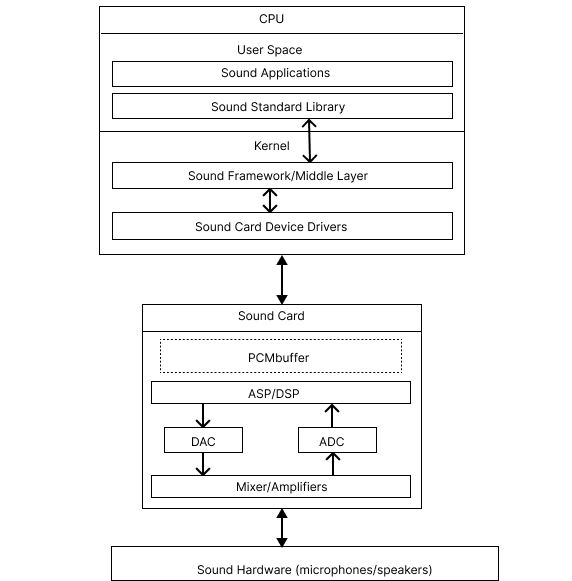

The software stack on the CPU typically consist of
* Sound device drivers - drivers interact with the sound cards, mainly reading and writing to the PCM buffer's to play and record sound.
* Sound framework/middle layer - has the framework to support various sound cards (PCI,USB, etc.) and provides a standard API to the user space. This is in the kernel space.
* Sound standard library - This is a higher level api to the framework in the user space.
* Applications - Applications use the sound standard library API. These are typically client-server applications that do the audio recording, playback, mixing etc. PulseAudio is a very popular sound application. 

The audio framework on Linux is called Advanced Linux Sound Architecture(ALSA).

## Audio digital data format
Sound consisting of waves is converted to electical form by a transducer, such as a microphone. An ADC converts analog voltages to discrete values, called samples, at regular intervals in time known as the sampling rate. By sending these samples back to DAC and an output transducer like a speaker, the orginal sound can be reproduced.

These samples are stored as a sequence of numbers, which are amplitude values along the Y axis. The samples sequence number (position), determines time along the X axis. The sample rate and samples sequence number determine the actual time of the given position. The size of the samples, expressed in number of bits, is one factor that determines how accurately the sound is represented in digital form. The other major factor affecting sound quality is the sampling rate.

## ALSA framework
The ALSA framework is a series of kernel device drivers and software framework to support many different sound cards. It also provides an API library, libasound. Application developers are encouraged to use this higher level API. So the developers need not be aware of the low level details such as the device files, they can use the logical naming of the devices in the library. ALSA has the capability called plugins that allows extensions to new devices, including virtual devices implemented entirely in software. ALSA also provides a number of command line utilities like mixer, sound file player etc.

The ALSA API can be broken down into the below major interfaces
 * Control interface: For managing sound card registers and querying the available devices
 * PCM interface: For managing digital audio capture and playback
 * MIDI interface: This API provides access to a MIDI bus on the sound card. MIDI is Musical Instrumentation Digital Interface, a standard for electronic music instruments.
 * Timer interface: Provides access to the timing hardware on sound cards used for synchronizing sound events.
 
Each of this interface corresponds to an individual component on the sound card.

## Getting started with ALSA application programming
* Device Naming: The library API works with logical device names rather than device files. The devices can be real hardware devices or plugins. Hardware devices use the format hw:i,j , where i is the card number and j is the device on the card. The first sound device is hw:0,0. Default refers to the first sound device. Plugins use other unique names.

* Sound Buffers and Data Transfer: The sound card has a hardware buffer called PCM buffer that stores recorded samples. When the buffer is full it generates an interrupt. The kernel sound driver then uses direct memory access(DMA) to transfer the samples to an application buffer in memory. Similarly for playback, another application buffer in transfered from memory to the sound card's hardware buffer using DMA. The size of the buffer can be programmed by the ALSA library calls. ALSA splits the buffer up into a series of frames, each frame has one sample data. Full buffer data is called a period and transfer is done in units of a period. For sterio device the frame could contain 2 samples one for each channel(left and right speakers).

* Opening PCM Device and Setting Parameters: The application program must be linked to the ALSA library 'libasound' and the libraries API header file asoundlib.h must be included. Then we can call the library method snd_pcm_open to open the PCM device for playback or recording. snd_pcm_open returns a handle that is used in subsequent calls to the library methods to manipulate the PCM stream, set and get parameters.

```C++
#include <alsa/asoundlib.h>

// open the default pcm device in playback access mode
int rc;
snd_pcm_t *handle;
rc = snd_pcm_open(&handle, "default", SND_PCM_STREAM_PLAYBACK, 0);

//allocate hardware parameters object
snd_pcm_hw_params_t *params;
snd_pcm_hw_params_alloca(&params);

//fill it with default values
snd_pcm_hw_params_any(handle, params);

//set the desired sound parameters
snd_pcm_hw_params_set_access(handle, params, SND_PCM_ACCESS_RW_INTERLEAVED); // Interleaved mode
snd_pcm_hw_params_set_format(handle, params, SND_PCM_FORMAT_S16_LE); // Signed 16-bit little-endian format
snd_pcm_hw_params_set_channels(handle, params, 2); //set 2 channels, sterio
int dir;
unsigned int val = 44100;
snd_pcm_hw_params_set_rate_near(handle, params, &val, &dir); //set the sampling rate

//write the parameters to the driver
rc = snd_pcm_hw_params(handle, params);
```
The access is set to interleaved mode, this means each frame should contian 2 samples for a 2 channel PCM device(2 speakers). The data format is set to SND_PCM_FORMAT_S16_LE, which means the sample should be of 16 bits.

* Sound Playback: Now we try to read from standard input and write to the default PCM device. This example program plays 5 seconds of data. Code to open the PCM device for playback and setting of the desired parameters remains the same as about. In addition to the above parameters the period size must also be set. Now extend the program to create a buffer large enough to hold one period. Since we have to play the audio for 5 seconds, we have to loop through 5 seconds warth of periods.

```C++
// Set period size to 32 frames
frames = 32;
snd_pcm_hw_params_set_period_size_near(handle, params, &frames, &dir);

// Allocate a buffer large enough to hold one period
snd_pcm_hw_params_get_period_size(params, &frames, &dir);
int size = frames * 4; // 2 bytes/sample, 2 channels
buffer = (char *) malloc(size);

// we want to loop for 5 seconds
snd_pcm_hw_params_get_period_time(params, &val, &dir);
long loops = 5000000 / val; // loop count = 5 seconds/period time

while (loops > 0) 
{
    loops--;
    rc = read(0, buffer, size); // read buffer size of data from standard input(one period)
    rc = snd_pcm_writei(handle, buffer, frames); // write the buffer to the PCM device, play
}

snd_pcm_drain(handle);
snd_pcm_close(handle);
free(buffer);
```
This program loops until five seconds' worth of frames has been transferred or end of file read occurs on the input. We then call snd_pcm_drain to allow any pending sound samples to be transferred, then close the stream. We free the dynamically allocated buffer and exit. This program is not useful unless the input is redirected to something other than the console. We can use the random device as input to produce random white noise.

./sample_playback < /dev/urandom

* Sound Recording: Sound recording is similar to sound playback except that we perform PCM capture. When we open the PCM device we specify the mode as SND_PCM_STREAM_CAPTURE. In the loop, we read the samples from the sound hardware using snd_pcm_readi and write it to standard output using write. The rest of the code is same as the above program.

```C++
// open the default pcm device in capture access mode
int rc;
snd_pcm_t *handle;
rc = snd_pcm_open(&handle, "default", SND_PCM_STREAM_CAPTURE, 0);

while (loops > 0) 
{
    loops--;
    rc = snd_pcm_readi(handle, buffer, frames); // read buffer size of data from the default PCM device, record
    rc = write(1, buffer, size); // write the buffer to the standard output
}
```

The program records approximately five seconds of data and sends it to standard out. We should redirect it to a file.
./sample_record > sound.raw

Then we can use the previous program to playback the data.
./sample_playback < sound.raw

If the sound card supports full duplex sound, we should be able to pipe the programs together and hear the recorded sound coming out of the sound card.
./sample_record | ./sample_playback

* More Info: In the previous examples, the PCM streams were operating in blocking mode, that is, the calls would not return until the data had been transferred. ALSA allows opening a stream in nonblocking mode where the read and write functions return immediately. In this asynchronous mode, callbacks are used to handle events. In methods snd_pcm_readi and snd_pcm_writei, the letter i indicates that the frames are interleaved. Corresponding functions exist for non-interleaved mode. Also, ALSA supports opening a PCM channel in mmap mode, which allows efficient zero copy access of the sound data.

## Getting started with soundcard driver